In [1]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch.optim as optim
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn

In [2]:
torch.manual_seed(42)

In [3]:
df=pd.read_csv("fmnist_small.csv")
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5995,1,0,0,0,0,0,0,0,0,0,...,69,12,0,0,0,0,0,0,0,0
5996,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5997,8,0,0,0,0,0,0,0,0,0,...,39,47,2,0,0,29,0,0,0,0
5998,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


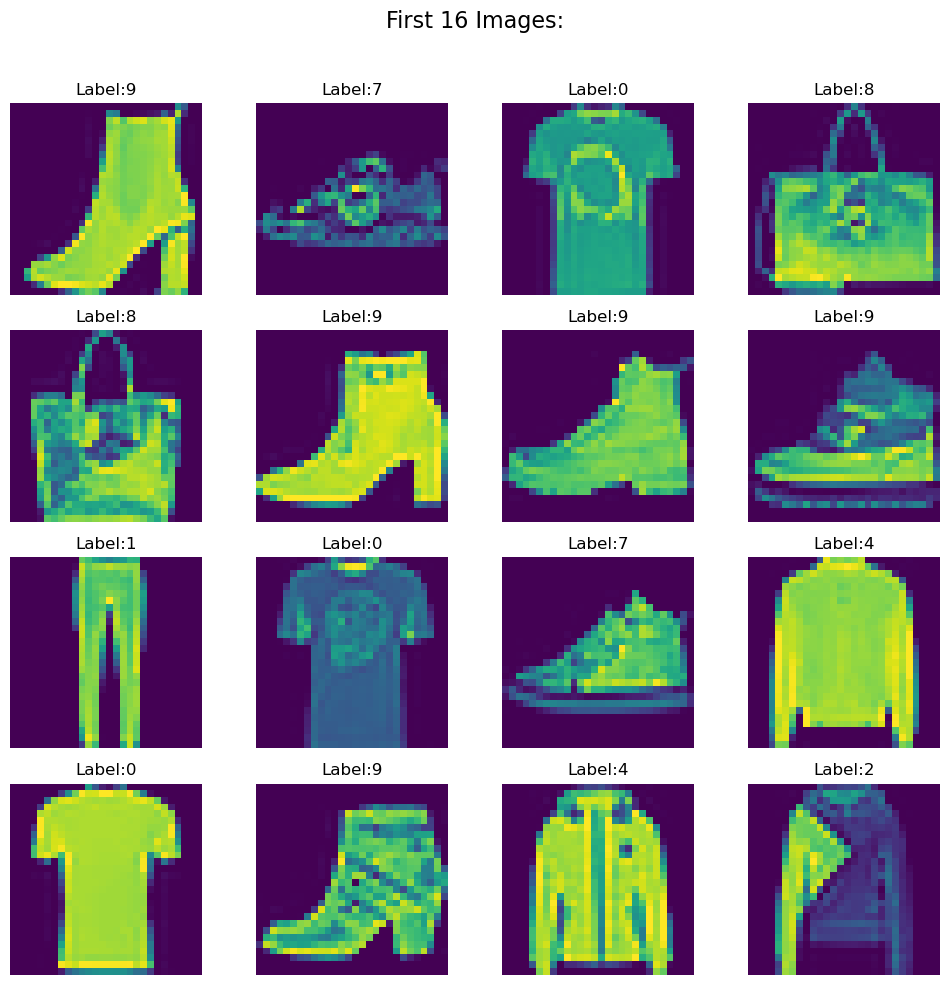

In [4]:
#created 4*4 grid to show the images
fig,axes=plt.subplots(4,4,figsize=(10,10))
fig.suptitle("First 16 Images:",fontsize=16)

for i,ax in enumerate(axes.flat):
    img=df.iloc[i,1:].values.reshape(28,28)
    ax.imshow(img)
    ax.axis('off')
    ax.set_title(f"Label:{df.iloc[i,0]}")
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

In [5]:
x=df.iloc[:,1:].values
y=df.iloc[:,0].values

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
#scaling the features
x_train=x_train/255.0
x_test=x_test/255.0

In [8]:
class customdataset(Dataset):
    def __init__(self,features,labels):
        self.features=torch.tensor(features,dtype=torch.float32)
        self.labels=torch.tensor(labels,dtype=torch.long)
        
    def __len__(self):
        return len(self.features)

    def __getitem__(self,index):
        return self.features[index],self.labels[index]

    
    
    

In [9]:
train_dataset=customdataset(x_train,y_train)

In [10]:
len(train_dataset)

4800

In [11]:
test_dataset=customdataset(x_test,y_test)


In [12]:
len(test_dataset)

1200

In [13]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32,shuffle=False)

In [14]:
class myNN(nn.Module):
    def __init__(self,num_features):
        super().__init__()
        self.model=nn.Sequential(
            nn.Linear(num_features,128),
            nn.ReLU(),
            nn.Linear(128,64),
            nn.ReLU(),
            nn.Linear(64,10)
        )
    def forward(self,x):
        return self.model(x)

In [15]:
epochs=100
learning_rate=0.1

In [16]:
#instatiate model
model=myNN(x_train.shape[1])
criterion=nn.CrossEntropyLoss()
optimizer=optim.SGD(model.parameters(),lr=learning_rate)

In [17]:
#training process
for epoch in range(epochs):
    total_epoch_loss=0
    for batch_features,batch_labels in train_loader:
        outputs=model(batch_features)
        loss=criterion(outputs,batch_labels)

        optimizer.zero_grad()
        loss.backward()

        #update steps
        optimizer.step()
        total_epoch_loss=total_epoch_loss+ loss.item()
    avg_epoch_loss=total_epoch_loss/len(train_loader)
    print(f"Epoch:{epoch+1},Loss:{avg_epoch_loss}")

Epoch:1,Loss:1.3216368520259858
Epoch:2,Loss:0.7793365579843521
Epoch:3,Loss:0.6427524695793788
Epoch:4,Loss:0.5751657489935557
Epoch:5,Loss:0.5281801910201709
Epoch:6,Loss:0.4952874990304311
Epoch:7,Loss:0.46024329950412113
Epoch:8,Loss:0.43594589988390603
Epoch:9,Loss:0.4182921428481738
Epoch:10,Loss:0.3984092238545418
Epoch:11,Loss:0.38502645591894785
Epoch:12,Loss:0.372268552283446
Epoch:13,Loss:0.34773620883623757
Epoch:14,Loss:0.34672420596083003
Epoch:15,Loss:0.31388126537203787
Epoch:16,Loss:0.31264611408114434
Epoch:17,Loss:0.2955209298928579
Epoch:18,Loss:0.28571509405970574
Epoch:19,Loss:0.27084775634109975
Epoch:20,Loss:0.26237100263436636
Epoch:21,Loss:0.25756084914008776
Epoch:22,Loss:0.24232647344470024
Epoch:23,Loss:0.2395794931302468
Epoch:24,Loss:0.22613244988024234
Epoch:25,Loss:0.22336848246554533
Epoch:26,Loss:0.213457190990448
Epoch:27,Loss:0.21694445793827374
Epoch:28,Loss:0.2088823829839627
Epoch:29,Loss:0.18397820924719174
Epoch:30,Loss:0.18893054623156785
Epoc

In [18]:
#set model to eval mode
model.eval()

myNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [19]:
#evaluvation code
total=0
correct=0
with torch.no_grad():
    for batch_features,batch_labels in train_loader:
        outputs=model(batch_features)
        _,predicted=torch.max(outputs,1)
        total=total+batch_labels.shape[0]
        correct=correct+(predicted==batch_labels).sum().item()
print("Accuracy of the model:",correct/total)
        

Accuracy of the model: 0.9854166666666667
